In [1]:
import utils as ut
from PIL import  ImageDraw
import cv2, random

2024-08-27 14:47:58.750244: I tensorflow/core/util/port.cc:113] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2024-08-27 14:47:58.782723: E external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:9261] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
2024-08-27 14:47:58.782753: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:607] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
2024-08-27 14:47:58.783726: E external/local_xla/xla/stream_executor/cuda/cuda_blas.cc:1515] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
2024-08-27 14:47:58.789566: I tensorflow/core/platform/cpu_feature_guar

In [2]:
def add_noise(image, size='big', noise_type='noisy', rgb=False):
    """
    Add a random noise area to the upper or lower half of the image, close to the middle.

    Parameters:
    - image: PIL.Image object.
    - shape: Shape of the noise area ('circle', 'square', or 'polygon').
    - size: string indicating the size of the noise area ('big', 'mid', 'lil').

    Returns:
    - image with added noise area.
    """
    image = image.copy()
    draw = ImageDraw.Draw(image)
    shapes = ['circle', 'square']#, 'polygon']
    shape = shapes[random.randint(0, len(shapes) -1 )]

    #big 40x40 medium 20x20 small 10x10
    if size == 'big':
        x1, y1 = random.randint(66, 129), 105
        x2, y2 = x1+40, y1+40
    elif size == 'mid':
        x1, y1 = random.randint(66, 149), random.randint(106, 124)
        x2, y2 = x1+20, y1+20
    elif size == 'lil':
        x1, y1 = random.randint(66, 159), random.randint(106, 134)
        x2, y2 = x1+10, y1+10

    bbox = (x1, y1, x2, y2)

    if noise_type == 'plain':
        fill_color = 255        # Plain white
        if rgb: fill_color = (255, 255, 255)
    elif noise_type == 'noisy':
        fill_color = 255
        if rgb: fill_color = tuple(random.randint(200, 215) for _ in range(3))  # Noisy white

    # if bbox:
    if shape == 'circle':
        draw.ellipse(bbox, fill=fill_color)
    elif shape == 'square':
        draw.rectangle(bbox, fill=fill_color)
        # print('square')

    return image

In [3]:
ds = ut.siamese_noise_dataset_new(shuffle=True, resize=True)

In [4]:
ds

DatasetDict({
    train: Dataset({
        features: ['slice1', 'slice2', 'label'],
        num_rows: 2520
    })
    test: Dataset({
        features: ['slice1', 'slice2', 'label'],
        num_rows: 315
    })
    valid: Dataset({
        features: ['slice1', 'slice2', 'label'],
        num_rows: 315
    })
})

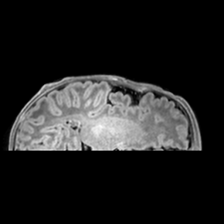

In [17]:
im = ds['train']['slice2'][18]
im

In [6]:
im.save("im.png")

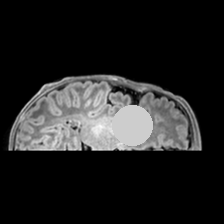

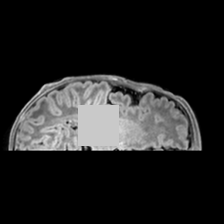

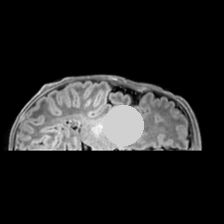

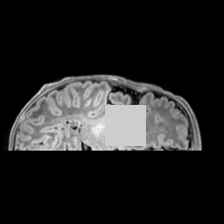

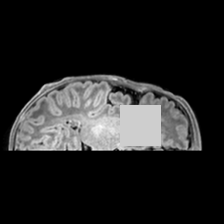

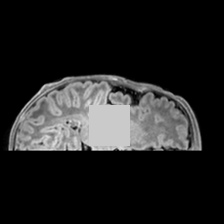

In [18]:
for i in range(6):
    display(add_noise(im, size='big', rgb=False))

In [8]:
def noisetest(image):
    image1 = image.copy()
    image2 = image.copy()
    image3 = image.copy()
    draw1 = ImageDraw.Draw(image1)
    draw2 = ImageDraw.Draw(image2)
    draw3 = ImageDraw.Draw(image3)


    # bbox = (65, 105, 170, 145)

    # big
    x = random.randint(66, 129)
    bbox1 = (x, 105, x+40, 145)
    # mediun
    x = random.randint(66, 149)
    y = random.randint(106, 124)
    bbox2 = (x, y, x+20, y+20)
    # small
    x = random.randint(66, 159)
    y = random.randint(106, 134)
    bbox3 = (x, y, x+10, y+10)

    fill_color = 255
    # draw.rectangle(bbox, fill=fill_color)
    draw1.ellipse(bbox1, fill=fill_color)
    draw2.ellipse(bbox2, fill=fill_color)
    draw3.ellipse(bbox3, fill=fill_color)
    # draw1.rectangle(bbox1, fill=fill_color)
    # draw2.rectangle(bbox2, fill=fill_color)
    # draw3.rectangle(bbox3, fill=fill_color)


    return image1, image2, image3

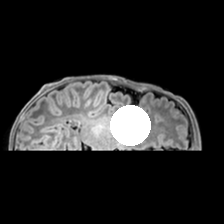

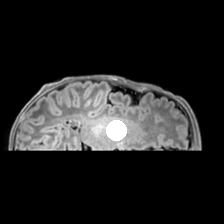

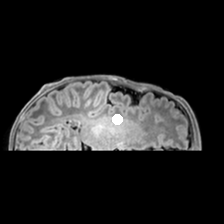

In [23]:
for i in noisetest(im): display(i) 

Image deformation

In [20]:
from PIL import Image, ImageDraw
import random

def add_noise(image, size='big', noise_type='noisy', rgb=False):
    """
    Add a random noise area to the upper or lower half of the image, close to the middle.

    Parameters:
    - image: PIL.Image object.
    - size: string indicating the size of the noise area ('big', 'mid', 'lil').
    - noise_type: string indicating the type of noise ('plain' or 'noisy').
    - rgb: boolean indicating if the image is RGB (True) or grayscale (False).

    Returns:
    - image with added noise area.
    """
    image = image.copy()
    draw = ImageDraw.Draw(image)
    
    # Define size parameters
    size_params = {
        'big': (40, 40, 66, 129, 105, 105),
        'mid': (20, 20, 66, 149, 106, 124),
        'lil': (10, 10, 66, 159, 106, 134)
    }
    
    w, h, x_min, x_max, y_min, y_max = size_params[size]
    
    # Generate random position
    x1 = random.randint(x_min, x_max)
    y1 = random.randint(y_min, y_max) if size != 'big' else y_min
    x2, y2 = x1 + w, y1 + h
    
    bbox = (x1, y1, x2, y2)
    
    # Determine fill color
    if noise_type == 'plain':
        fill_color = (255, 255, 255) if rgb else 255
    elif noise_type == 'noisy':
        if rgb:
            fill_color = tuple(random.randint(200, 215) for _ in range(3))
        else:
            fill_color = random.randint(200, 215)
    
    # Choose random shape
    shape = random.choice(['circle', 'square'])
    
    # Draw the shape
    if shape == 'circle':
        draw.ellipse(bbox, fill=fill_color)
    elif shape == 'square':
        draw.rectangle(bbox, fill=fill_color)
    
    return image

# Example usage:
# image = Image.open("path_to_your_image.png")
# augmented_image = add_noise(image, size='big', noise_type='noisy', rgb=True)
# augmented_image.save("augmented_image.png")

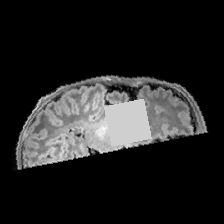

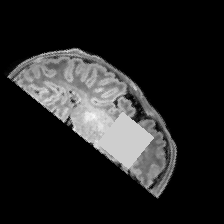

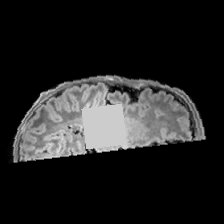

In [21]:
from torchvision import transforms

transform = transforms.RandomRotation(degrees=45)
# rotated_image = transform(image)

for i in range(3):
    display(transform(add_noise(im, size='big', rgb=False)))

In [1]:
import utils as ut
from datasets import load_dataset, DatasetDict, Dataset

2024-09-24 09:02:07.861734: I tensorflow/core/util/port.cc:113] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2024-09-24 09:02:07.895620: E external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:9261] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
2024-09-24 09:02:07.895647: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:607] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
2024-09-24 09:02:07.896685: E external/local_xla/xla/stream_executor/cuda/cuda_blas.cc:1515] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
2024-09-24 09:02:07.902930: I tensorflow/core/platform/cpu_feature_guar

In [2]:
hf_dataset = load_dataset("agucci/mri-sym2")

In [3]:
dst1 = hf_dataset['train'].map(ut.transforms, batched=True)
dst2 = hf_dataset['test'].map(ut.transforms, batched=True)

In [46]:
import matplotlib.pyplot as plt
import numpy as np

def noise_grid(image_pairs, output_file='noise_grid'):
    fig, axs = plt.subplots(2, 4, figsize=(16, 8))
    fig.suptitle(' ', fontsize=16)
    plt.subplots_adjust(wspace=0, hspace=0)
    xposes = [0.15, 0.39, 0.636, 0.875] # letters positions

    for i, (left_img, right_img) in enumerate(image_pairs):
        # left half
        axs[0, i].imshow(np.array(left_img), cmap='gray')
        axs[0, i].axis('off')
        # right half
        axs[1, i].imshow(np.array(right_img), cmap='gray')
        axs[1, i].axis('off')

        # Labels
        if i == 0:
            axs[0, i].text(-0.1, 0.5, 'Left', va='center', ha='right', transform=axs[0, i].transAxes, rotation=90, fontsize=18)
            axs[1, i].text(-0.1, 0.5, 'Right', va='center', ha='right', transform=axs[1, i].transAxes, rotation=90, fontsize=18)
        label = chr(65 + i)  # 65 is ASCII for 'A'
        fig.text(xpos:=(xposes[i]), 0.97, label, ha='center', va='center', fontsize=18, weight='bold')
        print(xpos)

    plt.tight_layout()
    plt.savefig(output_file+".png", bbox_inches='tight')
    plt.savefig(output_file+".eps", bbox_inches='tight')
    plt.show()
    plt.close()


In [5]:
ims = []

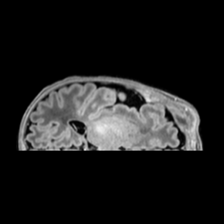

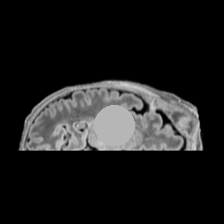

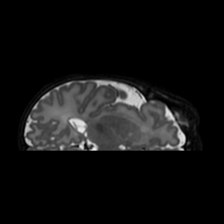

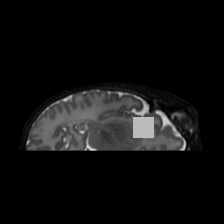

In [10]:
for i in range(1):
    display(im0:=dst1['slice1'][i])
    (im1:=dst1['slice2'][i])
    noised = ut.add_noise(im1, force_shape=0, size='big')
    display(noised)
    ims.append((im0, noised))

    display(im02:=dst2['slice1'][i])
    (im2:=dst2['slice2'][i])
    noised2 = ut.add_noise(im2, force_shape=1, size='mid')
    display(noised2)
    ims.append((im02, noised2))


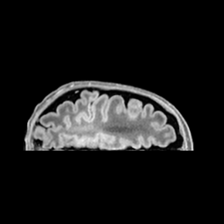

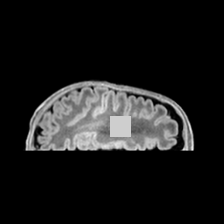

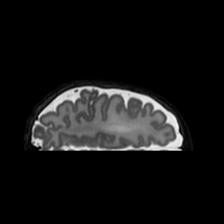

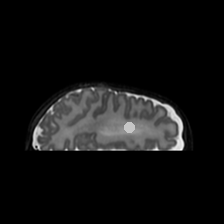

In [14]:
for i in range(1,2):
    display(im0:=dst1['slice1'][i])
    (im1:=dst1['slice2'][i])
    noised = ut.add_noise(im1, force_shape=1, size='mid')
    display(noised)
    ims.append((im0, noised))

    display(im02:=dst2['slice1'][i])
    (im2:=dst2['slice2'][i])
    noised2 = ut.add_noise(im2, force_shape=0, size='lil')
    display(noised2)
    ims.append((im02, noised2))

0.15
0.39
0.636
0.875


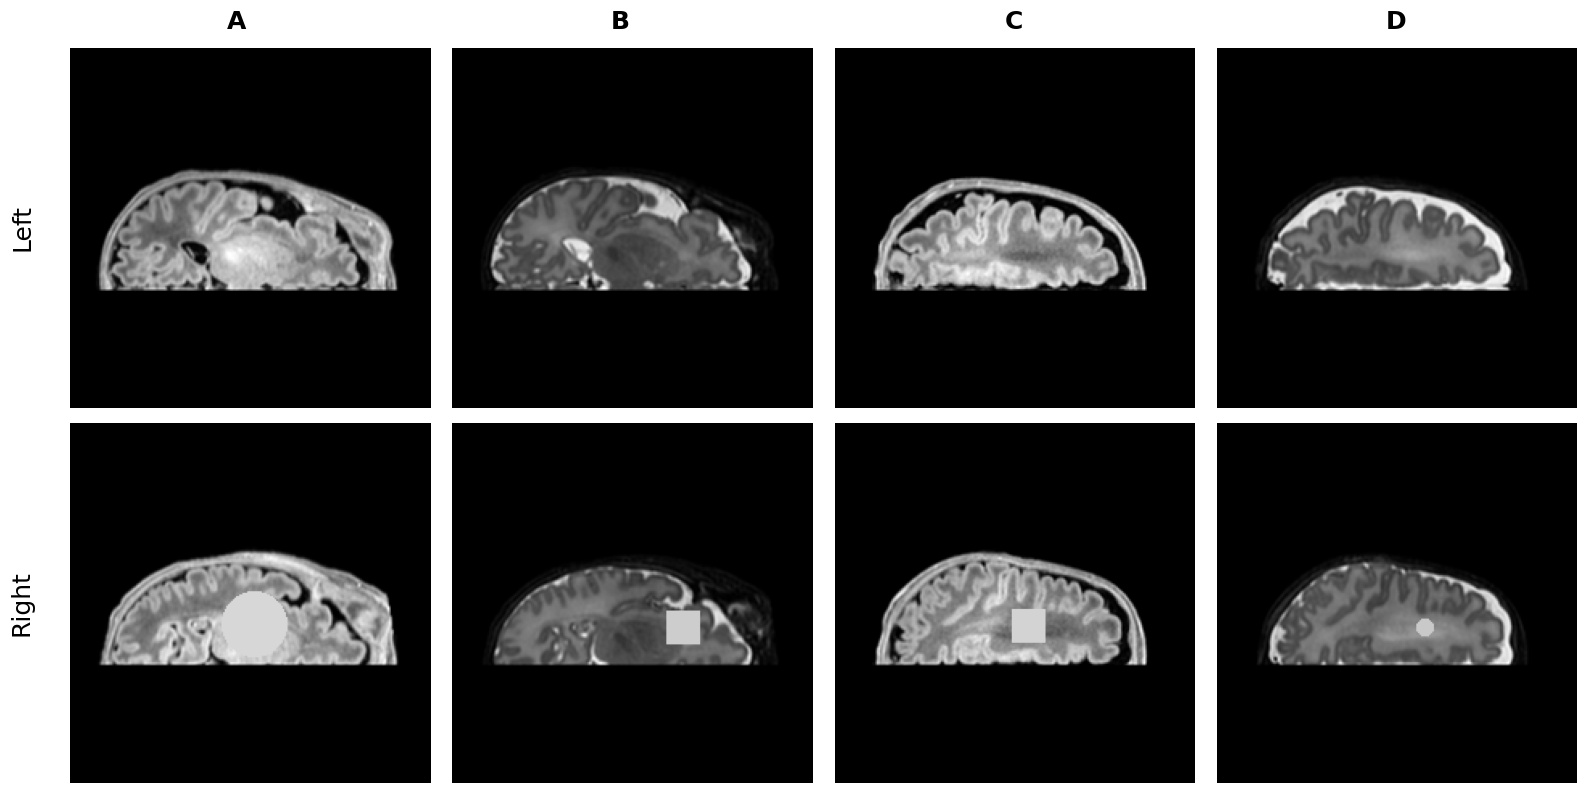

In [44]:
noise_grid(ims)

In [25]:
imsl = [list(p) for p in ims]
imsl

[[<PIL.PngImagePlugin.PngImageFile image mode=L size=224x224>,
  <PIL.Image.Image image mode=L size=224x224>],
 [<PIL.PngImagePlugin.PngImageFile image mode=L size=224x224>,
  <PIL.Image.Image image mode=L size=224x224>],
 [<PIL.PngImagePlugin.PngImageFile image mode=L size=224x224>,
  <PIL.Image.Image image mode=L size=224x224>],
 [<PIL.PngImagePlugin.PngImageFile image mode=L size=224x224>,
  <PIL.Image.Image image mode=L size=224x224>]]

In [26]:
imsl[1][0], imsl[1][1], imsl[2][0], imsl[2][1] = imsl[1][1], imsl[1][0], imsl[2][1], imsl[2][0]

0.15
0.39
0.636
0.875


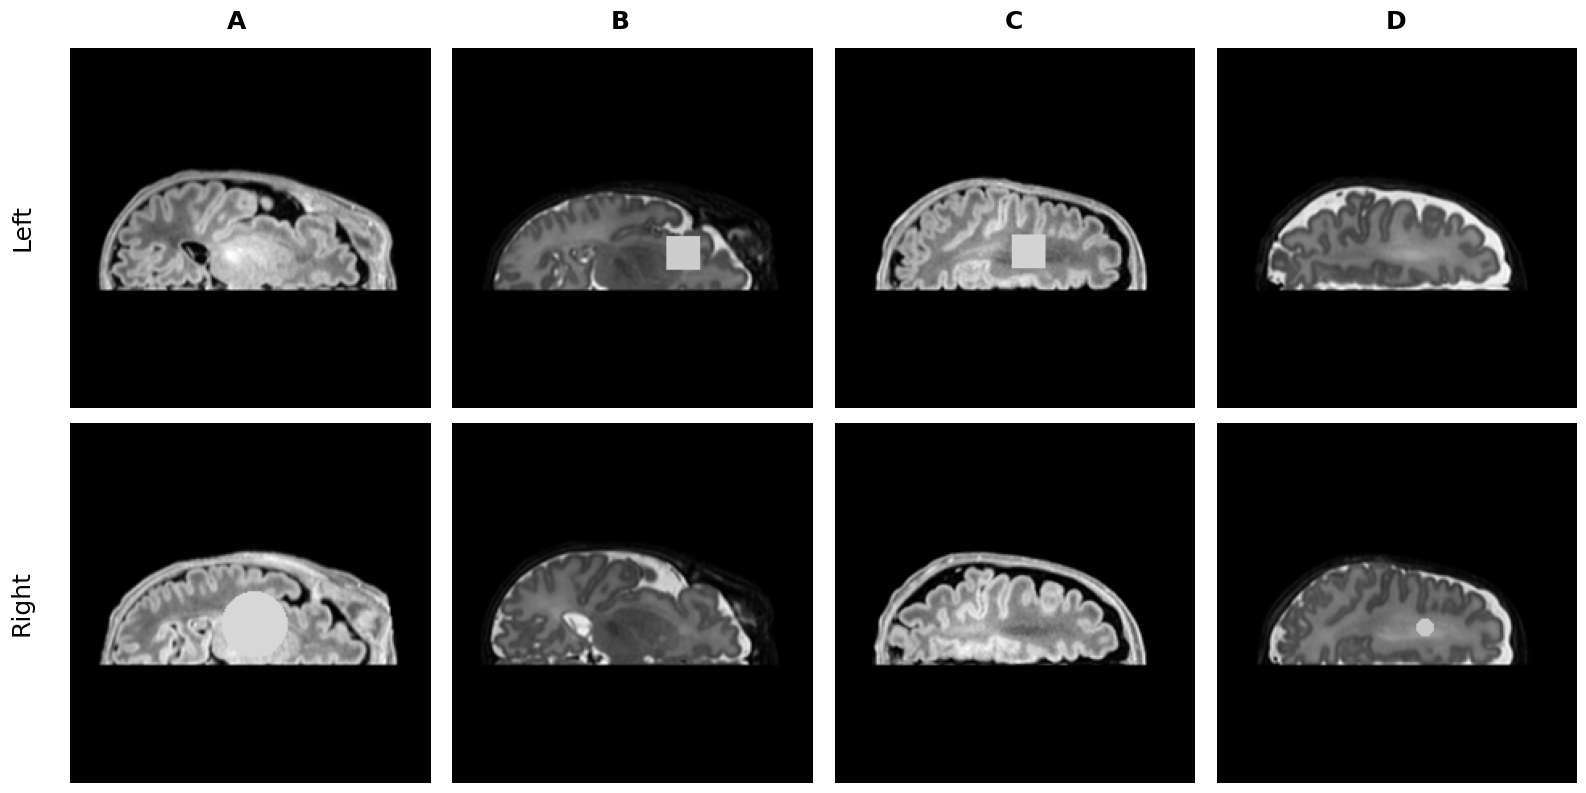

In [47]:
noise_grid(imsl)